# ENSEMBLE METHODS - titleType & rating

In [1]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold


In [2]:
path_X_train_tt = r"../../title/X_train_title_no_out.csv"
path_X_test_tt = r"../../title/X_test_title.csv"

path_y_train_tt = r"../../title/y_train_title_no_out.csv"
path_y_test_tt = r"../../title/y_test_title.csv"

In [3]:
path_X_train_rating = r"../../rating/X_train_rating_no_out.csv"
path_X_test_rating = r"../../rating/X_test_rating.csv"

path_y_train_rating = r"../../rating/y_train_rating_no_out.csv"
path_y_test_rating = r"../../rating/y_test_rating.csv"

In [4]:
X_train_tt = pd.read_csv(path_X_train_tt)
X_test_tt = pd.read_csv(path_X_test_tt)
y_train_tt = pd.read_csv(path_y_train_tt)
y_test_tt = pd.read_csv(path_y_test_tt)

In [5]:
X_train_rating = pd.read_csv(path_X_train_rating)
X_test_rating = pd.read_csv(path_X_test_rating)
y_train_rating = pd.read_csv(path_y_train_rating)
y_test_rating = pd.read_csv(path_y_test_rating)

In [6]:
X_train_tt = X_train_tt.drop(columns=["Unnamed: 0"], axis=1)
y_train_tt = y_train_tt["title_type"]
X_test_tt = X_test_tt.drop(columns=["Unnamed: 0"], axis=1)
y_test_tt = y_test_tt["title_type"]

In [7]:
X_train_rating = X_train_rating.drop(columns=["Unnamed: 0"], axis=1)
y_train_rating = y_train_rating["rating"]
X_test_rating = X_test_rating.drop(columns=["Unnamed: 0"], axis=1)
y_test_rating = y_test_rating["rating"]

### BAGGING - titleType

In [8]:
clf_tt = BaggingClassifier(
    estimator=DecisionTreeClassifier(
    class_weight="balanced", criterion="entropy", max_depth=None, min_samples_split=5, min_samples_leaf=5, 
    ),
    random_state=42, max_features=1.0, max_samples= 0.7, bootstrap= True
)

In [9]:
clf_tt.fit(X_train_tt, y_train_tt)
y_pred_tt = clf_tt.predict(X_test_tt)  

In [10]:
print(classification_report(y_test_tt, y_pred_tt))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91     10672
           1       0.92      0.96      0.94      4913
           2       0.98      0.95      0.96     21063
           3       0.44      0.49      0.46       467
           4       0.48      0.57      0.52      1755
           5       0.82      0.91      0.86      2647
           6       0.32      0.16      0.21        81
           7       0.38      0.54      0.45       311
           8       0.62      0.56      0.59      1494
           9       0.65      0.82      0.72       497

    accuracy                           0.90     43900
   macro avg       0.65      0.69      0.66     43900
weighted avg       0.90      0.90      0.90     43900



Confusion Matrix:
[[ 9635     1    58    12   619     6     0    45   231    65]
 [    0  4730    63     0    12     3    19     0    85     1]
 [  166   129 19916    67   294   258     3    71    73    86]
 [    0     0     3   227     2   207     1    14     5     8]
 [  469     6   132    14   993    17     0    45    63    16]
 [    1     0    19   164     7  2406     0    17    22    11]
 [    0    60     4     0     0     0    13     0     4     0]
 [   26    11    22     8    29    13     1   169    26     6]
 [  191   211    23    11    94    26     4    67   843    24]
 [   35     1     9     9     8     7     0    16     6   406]]


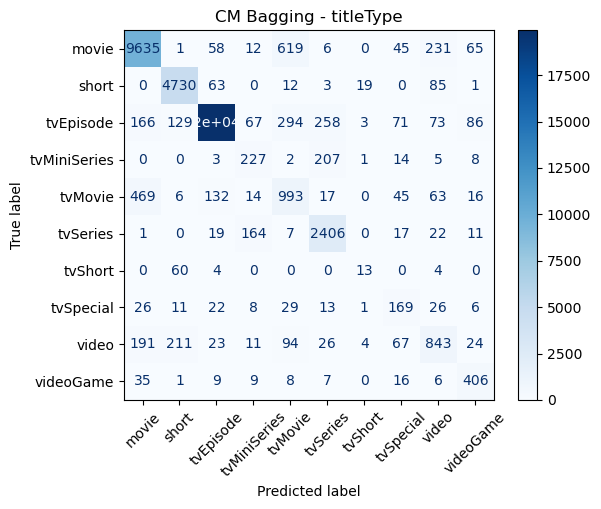

In [ ]:
cm = confusion_matrix(y_test_tt, y_pred_tt)

# Etichette
class_names = ['movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 
               'tvSeries', 'tvShort', 'tvSpecial', 'video', 'videoGame']

# Visualizzazione grafica con numeri più piccoli
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format='d', colorbar=True)

# Ridurre la dimensione dei numeri all'interno delle celle
for text in disp.text_.flatten():
    text.set_fontsize(8)  # puoi cambiare il numero per renderli più piccoli o più grandi

plt.title("CM Bagging - titleType")
plt.show()

In [12]:
# Calcola le performance sul training set
y_train_pred = clf_tt.predict(X_train_tt)

# Confronta le metriche
from sklearn.metrics import f1_score, accuracy_score

train_f1 = f1_score(y_train_tt, y_train_pred, average='weighted')
test_f1 = f1_score(y_test_tt, y_pred_tt, average='weighted')
train_acc = accuracy_score(y_train_tt, y_train_pred)
test_acc = accuracy_score(y_test_tt, y_pred_tt)

print(f"Training F1: {train_f1:.3f}")
print(f"Test F1: {test_f1:.3f}")
print(f"Differenza F1: {train_f1 - test_f1:.3f}")
print()
print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Differenza Accuracy: {train_acc - test_acc:.3f}")

# Interpretazione:
if (train_f1 - test_f1) > 0.05:
    print("⚠️ Possibile overfitting!")
elif (train_f1 - test_f1) < 0.02:
    print("✅ Buon bilanciamento bias-variance")
else:
    print("🟡 Leggero overfitting, ma accettabile")

Training F1: 0.943
Test F1: 0.898
Differenza F1: 0.044

Training Accuracy: 0.941
Test Accuracy: 0.896
Differenza Accuracy: 0.045
🟡 Leggero overfitting, ma accettabile


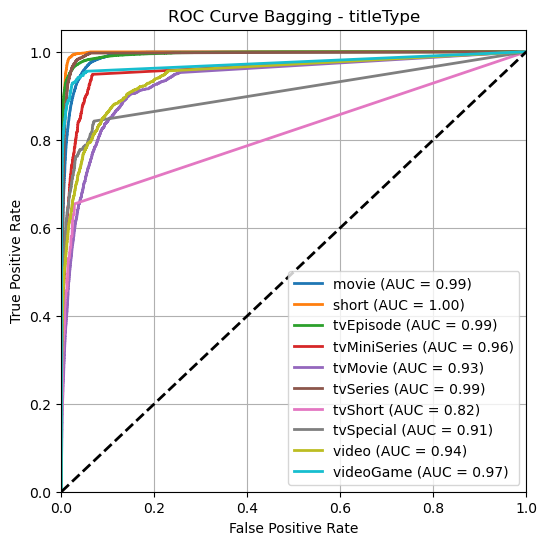

In [13]:
class_names = ['movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 'tvSeries', 'tvShort', 'tvSpecial', 'video', 'videoGame']

y_test_bin = label_binarize(y_test_tt, classes=range(len(class_names)))
n_classes = y_test_bin.shape[1]

y_score = clf_tt.predict_proba(X_test_tt)

plt.figure(figsize=(6,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Bagging - titleType')
plt.legend(loc='lower right')
plt.grid()
plt.show()

### ADABOOST - titletype

In [14]:
clf_tt = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(criterion="gini", max_depth=10, min_samples_leaf=5, min_samples_split=5),
    algorithm='SAMME',
    random_state=42,
    learning_rate=0.1,
    n_estimators=300,
)

In [15]:
clf_tt.fit(X_train_tt, y_train_tt)
y_pred_tt = clf_tt.predict(X_test_tt)  

c:\Users\Gagia\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


In [16]:
print(classification_report(y_test_tt, y_pred_tt))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92     10672
           1       0.93      0.97      0.95      4913
           2       0.98      0.98      0.98     21063
           3       0.62      0.44      0.52       467
           4       0.59      0.50      0.54      1755
           5       0.87      0.93      0.90      2647
           6       0.65      0.14      0.22        81
           7       0.63      0.44      0.52       311
           8       0.73      0.55      0.62      1494
           9       0.91      0.76      0.83       497

    accuracy                           0.92     43900
   macro avg       0.78      0.67      0.70     43900
weighted avg       0.92      0.92      0.92     43900



In [17]:
# Calcola le performance sul training set
y_train_pred = clf_tt.predict(X_train_tt)

# Confronta le metriche
from sklearn.metrics import f1_score, accuracy_score

train_f1 = f1_score(y_train_tt, y_train_pred, average='weighted')
test_f1 = f1_score(y_test_tt, y_pred_tt, average='weighted')
train_acc = accuracy_score(y_train_tt, y_train_pred)
test_acc = accuracy_score(y_test_tt, y_pred_tt)

print(f"Training F1: {train_f1:.3f}")
print(f"Test F1: {test_f1:.3f}")
print(f"Differenza F1: {train_f1 - test_f1:.3f}")
print()
print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Differenza Accuracy: {train_acc - test_acc:.3f}")

# Interpretazione:
if (train_f1 - test_f1) > 0.05:
    print("⚠️ Possibile overfitting!")
elif (train_f1 - test_f1) < 0.02:
    print("✅ Buon bilanciamento bias-variance")
else:
    print("🟡 Leggero overfitting, ma accettabile")

Training F1: 0.976
Test F1: 0.919
Differenza F1: 0.057

Training Accuracy: 0.976
Test Accuracy: 0.923
Differenza Accuracy: 0.054
⚠️ Possibile overfitting!


Confusion Matrix:
[[10132     0    48     9   339     6     0     7   119    12]
 [    0  4765    56     0     8     3     6     0    75     0]
 [   90    28 20722     3   129    66     0    15     7     3]
 [   10     1     7   205     4   228     0     6     3     3]
 [  624     4   171     4   873    16     0    14    47     2]
 [    5     5    39   100     4  2474     0     8    10     2]
 [    0    63     4     0     0     0    11     0     3     0]
 [   40     9    34     3    37    13     0   136    35     4]
 [  281   220    28     0    88    21     0    28   818    10]
 [   68     4    17     4     7     9     0     2    10   376]]


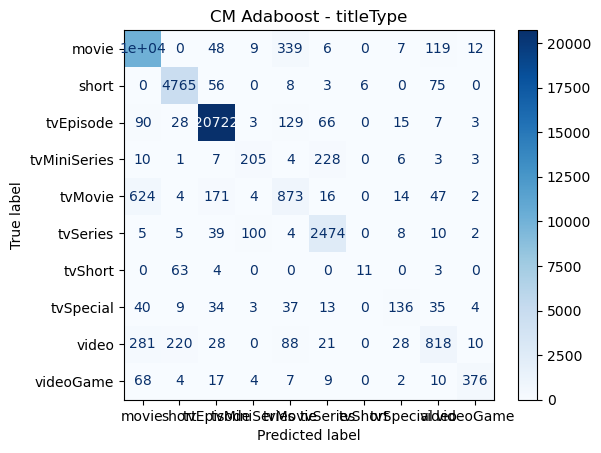

In [ ]:
cm = confusion_matrix(y_test_tt, y_pred_tt)

# Etichette
class_names = ['movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 
               'tvSeries', 'tvShort', 'tvSpecial', 'video', 'videoGame']

# Visualizzazione grafica con numeri più piccoli
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format='d', colorbar=True)

# Ridurre la dimensione dei numeri all'interno delle celle
for text in disp.text_.flatten():
    text.set_fontsize(8)  # puoi cambiare il numero per renderli più piccoli o più grandi

plt.title("CM Adaboost - titleType")
plt.show()

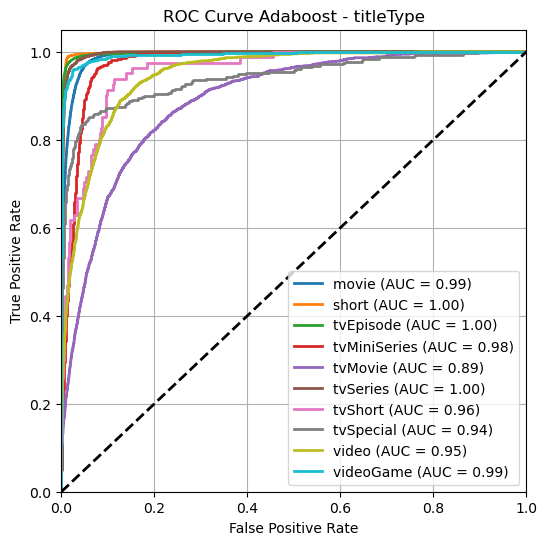

In [19]:
class_names = ['movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 'tvSeries', 'tvShort', 'tvSpecial', 'video', 'videoGame']

y_test_bin = label_binarize(y_test_tt, classes=range(len(class_names)))
n_classes = y_test_bin.shape[1]

y_score = clf_tt.predict_proba(X_test_tt)

plt.figure(figsize=(6,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Adaboost - titleType')
plt.legend(loc='lower right')
plt.grid()
plt.show()

### BAGGING - rating

In [20]:
clf_rating = BaggingClassifier(
    estimator=DecisionTreeClassifier(
    class_weight="balanced", 
    criterion='entropy', max_depth=50, min_samples_leaf=1, min_samples_split=2),
    random_state=42, bootstrap=True, max_features=0.7, max_samples=1.0, n_estimators=200
)

In [21]:
clf_rating.fit(X_train_rating, y_train_rating)
y_pred_rating = clf_rating.predict(X_test_rating)  

In [22]:
print(classification_report(y_test_rating, y_pred_rating))

              precision    recall  f1-score   support

           1       0.46      0.17      0.25        64
           2       0.39      0.08      0.13       192
           3       0.43      0.09      0.15       516
           4       0.39      0.14      0.20      1512
           5       0.39      0.22      0.28      3769
           6       0.42      0.43      0.42      8246
           7       0.45      0.55      0.49     13559
           8       0.50      0.60      0.54     11998
           9       0.52      0.20      0.29      3583
          10       0.66      0.19      0.30       461

    accuracy                           0.46     43900
   macro avg       0.46      0.27      0.31     43900
weighted avg       0.46      0.46      0.44     43900



In [23]:
# Calcola le performance sul training set
y_train_pred = clf_rating.predict(X_train_rating)

# Confronta le metriche
from sklearn.metrics import f1_score, accuracy_score

train_f1 = f1_score(y_train_rating, y_train_pred, average='weighted')
test_f1 = f1_score(y_test_rating, y_pred_rating, average='weighted')
train_acc = accuracy_score(y_train_rating, y_train_pred)
test_acc = accuracy_score(y_test_rating, y_pred_rating)

print(f"Training F1: {train_f1:.3f}")
print(f"Test F1: {test_f1:.3f}")
print(f"Differenza F1: {train_f1 - test_f1:.3f}")
print()
print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Differenza Accuracy: {train_acc - test_acc:.3f}")

# Interpretazione:
if (train_f1 - test_f1) > 0.05:
    print("⚠️ Possibile overfitting!")
elif (train_f1 - test_f1) < 0.02:
    print("✅ Buon bilanciamento bias-variance")
else:
    print("🟡 Leggero overfitting, ma accettabile")

Training F1: 0.998
Test F1: 0.441
Differenza F1: 0.557

Training Accuracy: 0.998
Test Accuracy: 0.458
Differenza Accuracy: 0.540
⚠️ Possibile overfitting!


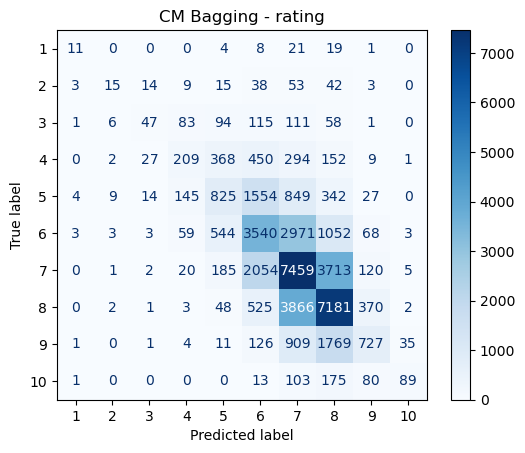

In [24]:
cm = confusion_matrix(y_test_rating, y_pred_rating)

# Etichette per i rating da 1 a 10
class_names = [str(i) for i in range(1, 11)]

# Visualizzazione grafica della confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)  # ruota le etichette x per leggibilità
plt.title("CM Bagging - rating")
plt.show()

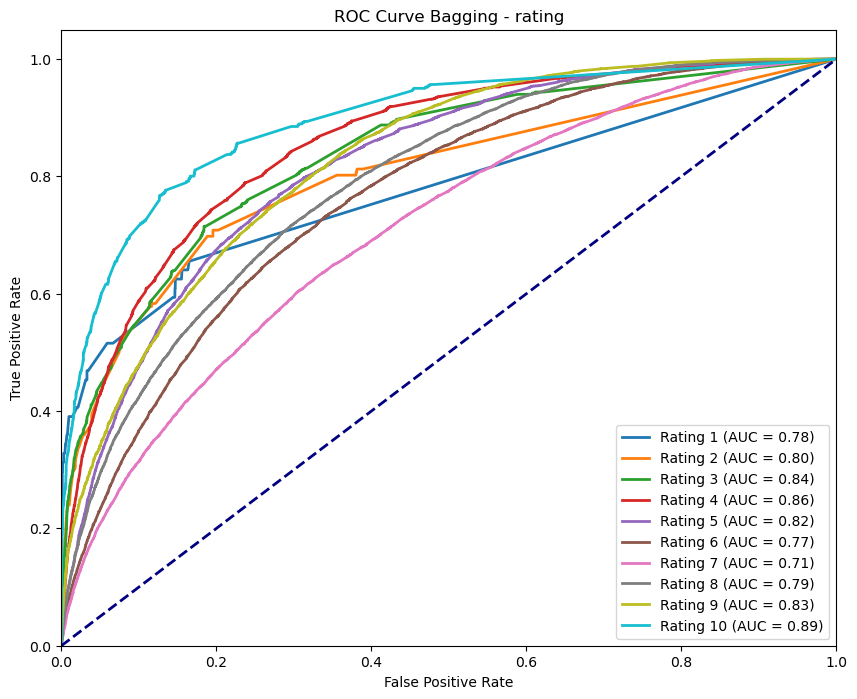

In [25]:
y_test_bin = label_binarize(y_test_rating, classes=list(range(1, 11)))
y_score = clf_rating.predict_proba(X_test_rating)

# Etichette
class_names = [str(i) for i in range(1, 11)]

# Creazione della ROC curve per ciascuna classe
plt.figure(figsize=(10, 8))
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[i][:,1] if isinstance(y_score, list) else y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Rating {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # linea casuale
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Bagging - rating')
plt.legend(loc='lower right')
plt.show()

### ADABOOST - rating

In [26]:
clf_rating = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_leaf=1, min_samples_split=5),
    algorithm='SAMME',  # ✅ AGGIUNTO: meglio per multiclasse
    random_state=42, learning_rate=0.1, n_estimators=300
)

In [27]:
clf_rating.fit(X_train_rating, y_train_rating)
y_pred_rating = clf_rating.predict(X_test_rating)  

c:\Users\Gagia\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


In [28]:
print(classification_report(y_test_rating, y_pred_rating))

              precision    recall  f1-score   support

           1       0.60      0.05      0.09        64
           2       0.58      0.04      0.07       192
           3       0.47      0.05      0.10       516
           4       0.34      0.13      0.19      1512
           5       0.35      0.23      0.27      3769
           6       0.40      0.38      0.39      8246
           7       0.42      0.53      0.47     13559
           8       0.46      0.56      0.50     11998
           9       0.39      0.16      0.23      3583
          10       0.62      0.11      0.19       461

    accuracy                           0.43     43900
   macro avg       0.46      0.22      0.25     43900
weighted avg       0.42      0.43      0.41     43900



In [29]:
# Calcola le performance sul training set
y_train_pred = clf_rating.predict(X_train_rating)

# Confronta le metriche
from sklearn.metrics import f1_score, accuracy_score

train_f1 = f1_score(y_train_rating, y_train_pred, average='weighted')
test_f1 = f1_score(y_test_rating, y_pred_rating, average='weighted')
train_acc = accuracy_score(y_train_rating, y_train_pred)
test_acc = accuracy_score(y_test_rating, y_pred_rating)

print(f"Training F1: {train_f1:.3f}")
print(f"Test F1: {test_f1:.3f}")
print(f"Differenza F1: {train_f1 - test_f1:.3f}")
print()
print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Differenza Accuracy: {train_acc - test_acc:.3f}")

# Interpretazione:
if (train_f1 - test_f1) > 0.05:
    print("⚠️ Possibile overfitting!")
elif (train_f1 - test_f1) < 0.02:
    print("✅ Buon bilanciamento bias-variance")
else:
    print("🟡 Leggero overfitting, ma accettabile")

Training F1: 0.600
Test F1: 0.409
Differenza F1: 0.191

Training Accuracy: 0.610
Test Accuracy: 0.426
Differenza Accuracy: 0.183
⚠️ Possibile overfitting!


Confusion Matrix:
[[   3    0    0    2    7    5   17   29    1    0]
 [   2    7    8   15   22   43   47   44    4    0]
 [   0    1   28   83  109  119  107   64    5    0]
 [   0    0   11  195  431  399  295  163   18    0]
 [   0    3    7  164  851 1380  910  419   35    0]
 [   0    1    3   60  646 3162 3076 1200   95    3]
 [   0    0    1   41  258 1921 7125 3963  243    7]
 [   0    0    1    9   87  617 4147 6706  421   10]
 [   0    0    0    3   21  164  992 1813  577   13]
 [   0    0    0    1    1   11  104  196   95   53]]


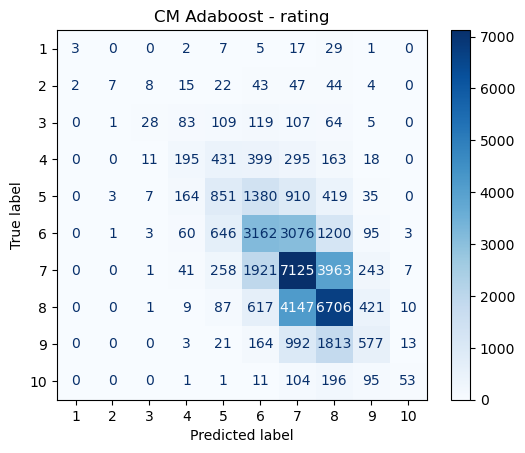

In [30]:
cm = confusion_matrix(y_test_rating, y_pred_rating)

# Stampa della confusion matrix numerica
print("Confusion Matrix:")
print(cm)

# Etichette per i rating da 1 a 10
class_names = [str(i) for i in range(1, 11)]

# Visualizzazione grafica della confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)  # ruota le etichette x per leggibilità
plt.title("CM Adaboost - rating")
plt.show()

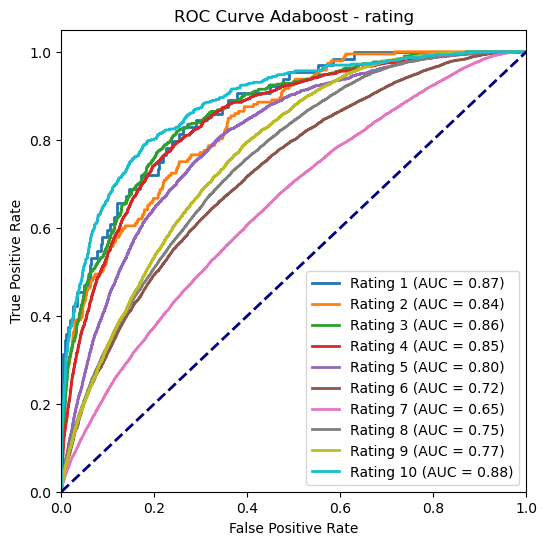

In [32]:
y_test_bin = label_binarize(y_test_rating, classes=list(range(1, 11)))
y_score = clf_rating.predict_proba(X_test_rating)

# Etichette
class_names = [str(i) for i in range(1, 11)]

# Creazione della ROC curve per ciascuna classe
plt.figure(figsize=(6, 6))
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[i][:,1] if isinstance(y_score, list) else y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Rating {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # linea casuale
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Adaboost - rating')
plt.legend(loc='lower right')
plt.show()